In [318]:
import torch
import torch.fft as fft
import numpy as np
# ---- parameters you can tweak ----
device = "cpu"
dtype  = torch.float64

# build plate / domain bounds
x_min, x_max = -0.0075, 0.0075   # example: 15 mm wide
y_min, y_max = -0.005,  0.005    # example: 10 mm deep

In [319]:
def gaussian_field_spectral(n_x, n_y, length_scale=10.0, device="cpu"):
    """
    Generates a smooth Gaussian random field using a squared-exponential spectrum.
    """
    # frequency grids
    kx = fft.fftfreq(n_x, device=device).reshape(-1, 1)
    ky = fft.fftfreq(n_y, device=device).reshape(1, -1)
    k2 = kx**2 + ky**2

    # power spectrum (Gaussian kernel in Fourier space)
    spectrum = torch.exp(-0.5 * (length_scale**2) * k2)

    # white noise in Fourier space
    noise = torch.randn(n_x, n_y, device=device)
    noise_hat = fft.fft2(noise)

    # apply filter and transform back
    field = fft.ifft2(noise_hat * spectrum).real

    # normalize to unit variance
    field = (field - field.mean()) / field.std()

    return field

In [320]:
x_chosen

13

In [321]:

import math
import torch

# ============================================================
# 0. Device / dtype
# ============================================================
device = "cpu"        # or "cuda" if available & desired
dtype  = torch.float64
torch.set_default_dtype(dtype)

# ============================================================
# 1. Geometry: coarse evenly spaced grid (same as before)
# ============================================================
width  = 0.015   # x-span
depth  = 0.010   # y-span
height = 0.002   # z-span

x_center = 0.0
y_center = 0.0
z_center = 0.0

x_min = x_center - width  / 2.0
x_max = x_center + width  / 2.0
y_min = y_center - depth  / 2.0
y_max = y_center + depth  / 2.0
z_min = z_center - height / 2.0
z_max = z_center + height / 2.0

# coarse grid you used before
n_x = 31
n_y = 21
n_z = 5

N_top = 31*21

x = torch.linspace(x_min, x_max, n_x, device=device, dtype=dtype)
y = torch.linspace(y_min, y_max, n_y, device=device, dtype=dtype)
z = torch.linspace(z_min, z_max, n_z, device=device, dtype=dtype)

dx = (x_max - x_min) / (n_x - 1)
dy = (y_max - y_min) / (n_y - 1)
dz = (z_max - z_min) / (n_z - 1)

X, Y, Z = torch.meshgrid(x, y, z, indexing="ij")  # shapes (n_x, n_y, n_z)

N_points = n_x * n_y * n_z  # should be 3255

# ============================================================
# 2. Material coefficients p(T), C(T), k(T) (your definitions)
# ============================================================

def p(T):
    """
    rho(T) from your piecewise polynomial definition.
    """
    T = torch.as_tensor(T, dtype=dtype, device=device)
    c1 = T < 4.0
    c2 = T < 93.0
    c3 = T < 1700.0

    const_4 = (
        7930.967
        + 0.03300298 * 4.0
        - 9.663581e-4 * 4.0**2
        - 2.917178e-6 * 4.0**3
    )
    poly_cubic = (
        7930.967
        + 0.03300298 * T
        - 9.663581e-4 * T**2
        - 2.917178e-6 * T**3
    )
    poly_quartic = (
        7945.333
        - 0.1981948 * T
        - 3.713764e-4 * T**2
        + 2.213069e-7 * T**3
        - 5.128456e-11 * T**4
    )
    const_1700 = (
        7945.333
        - 0.1981948 * 1700.0
        - 3.713764e-4 * 1700.0**2
        + 2.213069e-7 * 1700.0**3
        - 5.128456e-11 * 1700.0**4
    )

    return torch.where(
        c1,
        torch.tensor(const_4, dtype=dtype, device=device),
        torch.where(
            c2,
            poly_cubic,
            torch.where(
                c3,
                poly_quartic,
                torch.tensor(const_1700, dtype=dtype, device=device),
            ),
        ),
    )


def C(T):
    """
    Cp(T) piecewise polynomial, as in your PyTorch version.
    """
    T = torch.as_tensor(T, dtype=dtype, device=device)

    P1 = (
        4.80349978
        - 1.97398861 * T
        + 0.433444409 * T**2
        - 0.0314324757 * T**3
        + 8.32403453e-4 * T**4
    )
    P2 = (
        -0.224295746
        + 0.760568357 * T
        - 4.00750758e-2 * T**2
        + 2.18176061e-3 * T**3
        - 1.83602372e-5 * T**4
    )
    P3 = (
        8.9262753
        - 2.90098686 * T
        + 0.147079315 * T**2
        - 0.00125489708 * T**3
        + 3.41401137e-6 * T**4
    )
    P4 = (
        270.215021
        - 1.21051111 * T
        + 2.15156635e-2 * T**2
        - 7.51184063e-5 * T**3
        + 8.13679634e-8 * T**4
    )
    P5 = (
        109.207295
        + 2.5717751 * T
        - 6.52809855e-3 * T**2
        + 7.78752439e-6 * T**3
        - 4.16791252e-9 * T**4
        + 8.09061335e-13 * T**5
    )

    Cp_at_4 = (
        4.80349978
        - 1.97398861 * 4.0
        + 0.433444409 * 4.0**2
        - 0.0314324757 * 4.0**3
        + 8.32403453e-4 * 4.0**4
    )
    Cp_at_1311 = (
        109.207295
        + 2.5717751 * 1311.0
        - 6.52809855e-3 * 1311.0**2
        + 7.78752439e-6 * 1311.0**3
        - 4.16791252e-9 * 1311.0**4
        + 8.09061335e-13 * 1311.0**5
    )

    return torch.where(
        T < 4.0,
        torch.tensor(Cp_at_4, dtype=dtype, device=device),
        torch.where(
            T < 14.0,
            P1,
            torch.where(
                T < 47.0,
                P2,
                torch.where(
                    T < 128.0,
                    P3,
                    torch.where(
                        T < 310.0,
                        P4,
                        torch.where(
                            T < 1311.0,
                            P5,
                            torch.tensor(Cp_at_1311, dtype=dtype, device=device),
                        ),
                    ),
                ),
            ),
        ),
    )


def k_T(T):
    """
    k(T) piecewise polynomial, as in your PyTorch code.
    """
    T = torch.as_tensor(T, dtype=dtype, device=device)

    Q1 = (
        -0.03740871
        + 0.06460546 * T
        + 0.003720604 * T**2
        - 8.390067e-5 * T**3
        + 6.006594e-7 * T**4
    )
    Q2 = (
        -1.031521
        + 0.1813807 * T
        - 0.001088656 * T**2
        + 3.411681e-6 * T**3
        - 3.988389e-9 * T**4
    )
    Q3 = (
        -1.258169
        + 0.1023945 * T
        - 2.189547e-4 * T**2
        + 2.312931e-7 * T**3
        - 8.903937e-11 * T**4
    )

    k_at_1 = (
        -0.03740871
        + 0.06460546 * 1.0
        + 0.003720604 * 1.0**2
        - 8.390067e-5 * 1.0**3
        + 6.006594e-7 * 1.0**4
    )
    k_at_887 = (
        -1.258169
        + 0.1023945 * 887.0
        - 2.189547e-4 * 887.0**2
        + 2.312931e-7 * 887.0**3
        - 8.903937e-11 * 887.0**4
    )

    return torch.where(
        T < 1.0,
        torch.tensor(k_at_1, dtype=dtype, device=device),
        torch.where(
            T < 45.0,
            Q1,
            torch.where(
                T < 283.0,
                Q2,
                torch.where(
                    T < 887.0,
                    Q3,
                    torch.tensor(k_at_887, dtype=dtype, device=device),
                ),
            ),
        ),
    )

# ============================================================
# 3. Random laser paths and Gaussian flux along a polyline
# ============================================================

def make_random_polyline(
    num_segments,
    x_min, x_max, y_min, y_max,
    p_axis_aligned=0.5,
    device="cpu",
    dtype=torch.float64,
):
    """
    Generate a random polyline with num_segments segments
    inside [x_min,x_max]×[y_min,y_max].
    """
    x0 = torch.empty((), device=device, dtype=dtype).uniform_(x_min, x_max).item()
    y0 = torch.empty((), device=device, dtype=dtype).uniform_(y_min, y_max).item()

    xs = [x0]
    ys = [y0]

    for _ in range(num_segments):
        if torch.rand((), device=device) < p_axis_aligned:
            # axis aligned
            if torch.rand((), device=device) < 0.5:
                # horizontal
                x_new = torch.empty((), device=device, dtype=dtype).uniform_(x_min, x_max).item()
                y_new = y0
            else:
                # vertical
                x_new = x0
                y_new = torch.empty((), device=device, dtype=dtype).uniform_(y_min, y_max).item()
        else:
            # diagonal-ish
            x_new = torch.empty((), device=device, dtype=dtype).uniform_(x_min, x_max).item()
            y_new = torch.empty((), device=device, dtype=dtype).uniform_(y_min, y_max).item()

        xs.append(x_new)
        ys.append(y_new)
        x0, y0 = x_new, y_new

    return (
        torch.tensor(xs, device=device, dtype=dtype),
        torch.tensor(ys, device=device, dtype=dtype),
    )


def smooth_zigzag_flux(x, t, paths_x, paths_y, velocity, power, sigma,
                       *, dtype=torch.float64, device=None, return_focus=False):
    """
    Gaussian laser flux centered at a point that moves along a polyline at constant speed.
    """
    px = torch.as_tensor(paths_x, dtype=dtype, device=device)
    py = torch.as_tensor(paths_y, dtype=dtype, device=px.device)
    if px.numel() < 2:
        raise ValueError("Path must contain at least two points.")

    P = torch.stack([px, py], dim=-1)  # (N,2)

    x = torch.as_tensor(x, dtype=dtype, device=P.device)
    if x.shape[-1] != 2:
        raise ValueError("x must have shape (...,2)")

    t = torch.as_tensor(t, dtype=dtype, device=P.device)

    # segment lengths & cumulative distances
    seg = P[1:] - P[:-1]                       # (N-1,2)
    seg_len = torch.linalg.norm(seg, dim=-1)   # (N-1,)
    total_len = seg_len.sum()

    if total_len <= 0:
        focus = P[0]
    else:
        s = torch.remainder(t * velocity, total_len)  # distance along path
        cum = torch.cumsum(seg_len, dim=0)
        k = torch.searchsorted(cum, s).item()         # segment index

        s_prev = cum[k-1] if k > 0 else cum.new_zeros(())
        Lk = seg_len[k]
        alpha = (s - s_prev) / (Lk + (Lk == 0).to(dtype) * 1.0)
        alpha = torch.clamp(alpha, 0.0, 1.0)

        focus = P[k] + alpha * (P[k+1] - P[k])       # (2,)

    diff = x - focus
    r2 = (diff**2).sum(dim=-1)

    denom = math.pi * (2.0 * sigma)**2
    flux = (2.0 * power) / denom * torch.exp(-2.0 * r2 / (2.0 * sigma)**2)
    return (flux, focus) if return_focus else flux


# ============================================================
# 4. Finite difference: gradient + Laplacian with BCs
# ============================================================

def compute_grad_and_lap(T, q_top, dx, dy, dz):
    """
    Given T on full grid (n_x,n_y,n_z) and q_top(x,y,t) on the top plane,
    return (dTdx, dTdy, dTdz, Lap_T) using central differences in the interior
    and:
      - zero-flux side walls (Neumann 0) by mirroring
      - bottom Dirichlet T=T0 handled outside (we won't update that T)
      - top Neumann -k(T_top) * dT/dz = q_top via a ghost layer.
    """
    Nx, Ny, Nz = T.shape

    # pad T with one ghost layer in each direction
    Tpad = torch.zeros((Nx+2, Ny+2, Nz+2), device=T.device, dtype=T.dtype)
    Tpad[1:-1, 1:-1, 1:-1] = T

    # side Neumann (zero flux): mirror
    Tpad[0,   1:-1, 1:-1] = T[0,   :, :]   # x-left ghost = x=0
    Tpad[-1,  1:-1, 1:-1] = T[-1,  :, :]   # x-right ghost = x=Nx-1
    Tpad[1:-1, 0,   1:-1] = T[:,   0, :]   # y-front ghost = y=0
    Tpad[1:-1, -1,  1:-1] = T[:,  -1, :]   # y-back ghost  = y=Ny-1

    # bottom Dirichlet: T fixed = T[ :, :, 0] (we assume outside code enforces T0)
    Tpad[1:-1, 1:-1, 1] = T[:, :, 0]   # bottom plane
    Tpad[1:-1, 1:-1, 0] = T[:, :, 0]   # ghost below, same value

    # top Neumann: -k(T_top)* dT/dz = q_top  ==> ghost = T_top - dz*q_top/k_top
    T_top = T[:, :, -1]
    k_top = k_T(T_top)
    Tghost = T_top + dz * q_top / k_top  # shape (Nx,Ny)

    Tpad[1:-1, 1:-1, Nz]   = T_top
    Tpad[1:-1, 1:-1, Nz+1] = Tghost

    # central differences for derivatives on *domain* cells, using the padded array
    # dT/dx
    dTdx = (Tpad[2:, 1:-1, 1:-1] - Tpad[:-2, 1:-1, 1:-1]) / (2.0 * dx)
    # dT/dy
    dTdy = (Tpad[1:-1, 2:, 1:-1] - Tpad[1:-1, :-2, 1:-1]) / (2.0 * dy)
    # dT/dz
    dTdz = (Tpad[1:-1, 1:-1, 2:] - Tpad[1:-1, 1:-1, :-2]) / (2.0 * dz)

    # Laplacian ΔT
    lap = (
        (Tpad[2:, 1:-1, 1:-1] - 2.0 * Tpad[1:-1, 1:-1, 1:-1] + Tpad[:-2, 1:-1, 1:-1]) / dx**2
        + (Tpad[1:-1, 2:, 1:-1] - 2.0 * Tpad[1:-1, 1:-1, 1:-1] + Tpad[1:-1, :-2, 1:-1]) / dy**2
        + (Tpad[1:-1, 1:-1, 2:] - 2.0 * Tpad[1:-1, 1:-1, 1:-1] + Tpad[1:-1, 1:-1, :-2]) / dz**2
    )

    return dTdx, dTdy, dTdz, lap


# ============================================================
# 5. Time stepping loop and data storage
# ============================================================

# time stepping
dt       = 5e-4
T_final  = 0.064
Nt       = int(round(T_final / dt))   # 0.064 / 5e-4 = 128

# number of realizations (random laser paths)
num_realizations = 200

# top Neumann parameters
sigma_beam = 1e-4
velocity   = 0.3          # m/s
power      = 10.0

# initial temperature (ambient)
T0 = 293.15  # K, say

# allocate storage:
solutions      = torch.zeros((num_realizations, N_points, Nt+1), device=device, dtype=dtype)
solutions_dx   = torch.zeros_like(solutions)
solutions_dy   = torch.zeros_like(solutions)
solutions_dz   = torch.zeros_like(solutions)
solutions_Lap  = torch.zeros_like(solutions)
solutions_top_bc = torch.zeros((num_realizations, N_top, Nt+1),
                               device=device, dtype=dtype)

# precompute XY coords on top plane for evaluating q_top
XY_top = torch.stack([X[:, :, -1].reshape(-1), Y[:, :, -1].reshape(-1)], dim=1)  # (Nx*Ny,2)

# main loop over realizations
for m in range(num_realizations):
    # random laser path inside the laser "window" you care about
    # here I just use the whole plate; you can restrict if you want.
    num_segments   = 100
    
    
    
    p_axis_aligned = 0.5
    paths_x, paths_y = make_random_polyline(
        num_segments,
        x_min, x_max,
        y_min, y_max,
        p_axis_aligned=p_axis_aligned,
        device=device,
        dtype=dtype,
    )

    # initial T field: uniform T0
    T = T0 * torch.ones((n_x, n_y, n_z), device=device, dtype=dtype)

    # store t=0
    

    dTdx, dTdy, dTdz, lap = compute_grad_and_lap(
        T,
        q_top=torch.zeros((n_x, n_y), device=device, dtype=dtype),
        dx=dx, dy=dy, dz=dz,
    )
    solutions[m, :, 0]     = T.reshape(-1)
    solutions_dx[m, :, 0]  = dTdx.reshape(-1)
    solutions_dy[m, :, 0]  = dTdy.reshape(-1)
    solutions_dz[m, :, 0]  = dTdz.reshape(-1)
    solutions_Lap[m, :, 0] = lap.reshape(-1)
    # top BC functional at t=0: q_top = 0 ⇒ bc = 0
    T_top0  = T[:, :, -1]                  # (n_x, n_y)
    k_top0  = k_T(T_top0)
    q_top0  = torch.zeros_like(T_top0)
    bc0     = (q_top0 / k_top0).reshape(-1)  # shape (N_top,)
    solutions_top_bc[m, :, 0] = bc0

    # time loop
    for n in range(Nt):
        t = (n + 1) * dt

        # 1) compute q_top(x,y,t) from random polyline path
        # flux_top = smooth_zigzag_flux(
        #     XY_top, t,
        #     paths_x, paths_y,
        #     velocity=velocity,
        #     power=power,
        #     sigma=sigma_beam,
        #     dtype=dtype,
        #     device=device,
        #     return_focus=False,
        # ).reshape(n_x, n_y)
        x_chosen = int(np.random.uniform(low=10,high=21))
        y_chosen = int(np.random.uniform(low=5,high=16))
        flux_top = torch.zeros(n_x,n_y)
        flux_top[x_chosen,y_chosen] = 10**8
        #flux_top = gaussian_field_spectral(n_x,n_y)
        

        # 2) compute gradients & Laplacian at time n
        dTdx, dTdy, dTdz, lap = compute_grad_and_lap(T, flux_top, dx, dy, dz)

        # 3) update T explicitly:
        rho_n = p(T)
        Cp_n  = C(T)
        k_n   = k_T(T)

        # PDE: rho Cp dT/dt = ∇·(k ∇T)
        # we approximate ∇·(k∇T) ≈ k_n * ΔT  (using lap)
        div_term = k_n * lap

        T_new = T + dt * div_term / (rho_n * Cp_n)

        # enforce bottom Dirichlet T = T0 at z_min (k=0)
        T_new[:, :, 0] = T0

        # (side Neumann & top Neumann already encoded in the Laplacian construction)

        T = T_new

        # 4) store fields at time step n+1
        dTdx, dTdy, dTdz, lap = compute_grad_and_lap(T, flux_top, dx, dy, dz)

        solutions[m, :, n+1]     = T.reshape(-1)
        solutions_dx[m, :, n+1]  = dTdx.reshape(-1)
        solutions_dy[m, :, n+1]  = dTdy.reshape(-1)
        solutions_dz[m, :, n+1]  = dTdz.reshape(-1)
        solutions_Lap[m, :, n+1] = lap.reshape(-1)
                # 5) store top Neumann BC functional q_top / k(T_top) at time n+1
        T_top   = T[:, :, -1]                    # T at top plane at t_{n+1}
        k_top   = k_T(T_top)                     # k(T_top)
        bc_top  = (flux_top / k_top).reshape(-1) # shape (N_top,)
        solutions_top_bc[m, :, n+1] = bc_top

    print(f"Finished realization {m+1}/{num_realizations}")

Finished realization 1/200
Finished realization 2/200
Finished realization 3/200
Finished realization 4/200
Finished realization 5/200
Finished realization 6/200
Finished realization 7/200
Finished realization 8/200
Finished realization 9/200
Finished realization 10/200
Finished realization 11/200
Finished realization 12/200
Finished realization 13/200
Finished realization 14/200
Finished realization 15/200
Finished realization 16/200
Finished realization 17/200
Finished realization 18/200
Finished realization 19/200
Finished realization 20/200
Finished realization 21/200
Finished realization 22/200
Finished realization 23/200
Finished realization 24/200
Finished realization 25/200
Finished realization 26/200
Finished realization 27/200
Finished realization 28/200
Finished realization 29/200
Finished realization 30/200
Finished realization 31/200
Finished realization 32/200
Finished realization 33/200
Finished realization 34/200
Finished realization 35/200
Finished realization 36/200
F

In [335]:
int(np.random.uniform(low=5,high=16))

8

In [336]:
bc_top.shape

torch.Size([651])

In [337]:
torch.save(solutions,"heat_sol")
#torch.save(solutions_top_bc,"heat_top_bc")
torch.save(solutions_dx,"heat_dx")
torch.save(solutions_dy,"heat_dy")
torch.save(solutions_dz,"heat_dz")
torch.save(solutions_Lap,"heat_Lap")

In [338]:
# reshape solutions back to (n_x, n_y, n_z)
solutions_3d = solutions.view(num_realizations, n_x, n_y, n_z, Nt+1)
solutions_dx_3d = solutions_dx.view(num_realizations, n_x, n_y, n_z, Nt+1)
solutions_dy_3d = solutions_dy.view(num_realizations, n_x, n_y, n_z, Nt+1)
solutions_dz_3d = solutions_dz.view(num_realizations, n_x, n_y, n_z, Nt+1)
solutions_Lap_3d = solutions_Lap.view(num_realizations, n_x, n_y, n_z, Nt+1)

# If you prefer an explicit "slice" axis:
# shape: (num_realizations, n_z, Nt+1, n_x, n_y)
solutions_slices = solutions_3d.permute(0, 3, 4, 1, 2)
solutions_dx_slices = solutions_dx_3d.permute(0, 3, 4, 1, 2)
solutions_dy_slices = solutions_dy_3d.permute(0, 3, 4, 1, 2)
solutions_dz_slices = solutions_dz_3d.permute(0, 3, 4, 1, 2)
solutions_Lap_slices = solutions_Lap_3d.permute(0, 3, 4, 1, 2)

In [339]:
import matplotlib.pyplot as plt

In [340]:
solutions_top_bc.shape

torch.Size([200, 651, 129])

In [341]:
 (solutions_slices[:,4,:,:,:]-solutions_slices[:,3,:,:,:]).shape

torch.Size([200, 129, 31, 21])

In [342]:
heat_top_bc = (solutions_slices[:,4,:,:,:]-solutions_slices[:,3,:,:,:]).permute(0, 2, 3, 1).reshape(num_realizations, 651, 129)/dz
torch.save(heat_top_bc,"heat_top_bc")

In [343]:
heat_top_bc.shape

torch.Size([200, 651, 129])

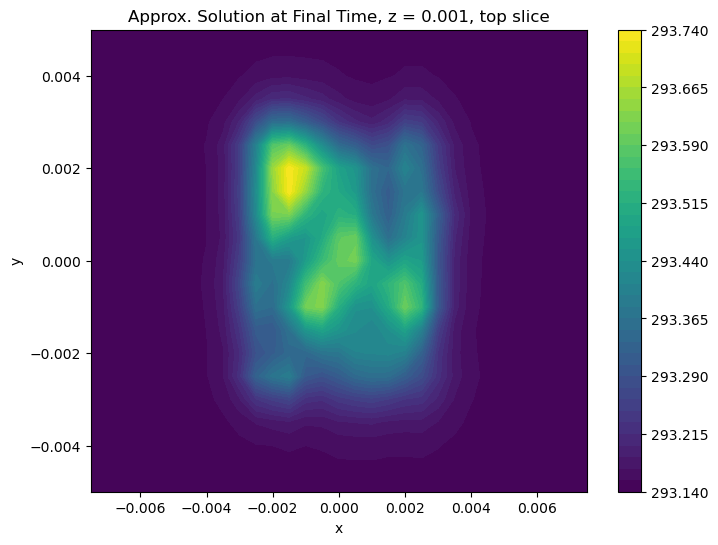

In [344]:
# --- 5. Plot interior of top layer ---
plt.figure(figsize=(8, 6))
cp2 = plt.contourf(
    X[:,:,-1],Y[:,:,-1],
   solutions_slices[90,1,-1,:,:],
    levels=50, cmap='viridis'
)
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, z = 0.001, top slice')
plt.show()

In [345]:
solutions_slices[0,2,128,:,:]

tensor([[293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500],
        [293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500],
        [293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500],
        [293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500,
         293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500, 293.1500],
        [293.1500, 293.1500, 293.1500, 293.1500,

In [346]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation  # or PillowWriter / FFMpegWriter
import os

# pick which realization to animate
m = 0  # 0 <= m < num_realizations

# folder to store videos/gifs
os.makedirs("animations", exist_ok=True)

def make_slice_animation(m, z_idx, cmap="inferno", save_gif=True, save_mp4=False):
    """
    Make a time animation of T(x,y,t) for a fixed z-slice = z[z_idx].
    """
    # data over time: (Nt+1, n_x, n_y)
    data = solutions_slices[m, z_idx]      # (Nt+1, n_x, n_y)
    data_cpu = data.cpu()                  # move to CPU for plotting

    # color scale fixed over time
    vmin = data_cpu.min().item()
    vmax = data_cpu.max().item()

    X_xy, Y_xy = torch.meshgrid(x, y, indexing="ij")
    X_xy = X_xy.cpu().numpy()
    Y_xy = Y_xy.cpu().numpy()

    fig, ax = plt.subplots(figsize=(5, 4))
    # imshow expects (ny, nx), so transpose
    im = ax.imshow(
        data_cpu[0].numpy().T,
        origin="lower",
        extent=[x_min, x_max, y_min, y_max],
        vmin=vmin, vmax=vmax,
        aspect="equal",
        cmap=cmap,
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Temperature (K)")

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(frame):
        im.set_data(data_cpu[frame].numpy().T)
        t_val = frame * dt
        ax.set_title(f"z = {z[z_idx].item():.4e} m, t = {t_val:.4f} s")
        return (im,)

    ani = FuncAnimation(
        fig,
        update,
        frames=Nt+1,       # use all time steps; can subsample if heavy
        interval=50,       # ms between frames
        blit=True,
    )

    fname_base = f"solution_m{m}_z{z_idx}"
    if save_gif:
        from matplotlib.animation import PillowWriter
        gif_path = os.path.join("animations", fname_base + ".gif")
        ani.save(gif_path, writer=PillowWriter(fps=20))
        print(f"Saved GIF: {gif_path}")

    if save_mp4:
        from matplotlib.animation import FFMpegWriter
        mp4_path = os.path.join("animations", fname_base + ".mp4")
        ani.save(mp4_path, writer=FFMpegWriter(fps=20))
        print(f"Saved MP4: {mp4_path}")

    plt.close(fig)  # avoids clutter in notebooks


# make an animation for every z-slice for realization m
for z_idx in range(n_z):
    make_slice_animation(m, z_idx, cmap="inferno", save_gif=True, save_mp4=False)

Saved GIF: animations/solution_m0_z0.gif
Saved GIF: animations/solution_m0_z1.gif
Saved GIF: animations/solution_m0_z2.gif
Saved GIF: animations/solution_m0_z3.gif
Saved GIF: animations/solution_m0_z4.gif


In [347]:
solutions.shape

torch.Size([200, 3255, 129])